# Customer Purchase Value Prediction

## Final submission for the Machine Learning Project course  
### IIT Madras Diploma in Data Science

This notebook predicts the purchase value generated by an anonymized e-commerce session using customer-behavior, acquisition-channel, device, and geographic attributes.

This is a cleaned public presentation of my final course-project submission. It preserves the four model workflows used for the project while:

- removing repeated imports and repeated dataset-loading cells;
- consolidating descriptive statistics;
- keeping the validation set separate from oversampling;
- standardizing evaluation on the original `purchaseValue` scale;
- saving a separate submission file for each model.

### Model roles

- **Primary model:** XGBoost Regressor  
  Selected as the main model because gradient boosting captured nonlinear interactions and performed best during the competition.

- **Secondary models:** Random Forest, Decision Tree, and Elastic Net  
  Included because the course project required comparison with additional machine-learning models.

The competition metric was **R²**.

## 1. Common setup

Shared imports, file discovery, evaluation, and submission helpers are defined once here to avoid repeating boilerplate. Each model section still contains its own cleaning, preprocessing, tuning, evaluation, and prediction workflow.

In [12]:
from __future__ import annotations

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from category_encoders import TargetEncoder
from scipy.stats import randint, uniform, zscore
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
TARGET = "purchaseValue"

# Set False for a quick test run. Set True before creating the final executed version.
FULL_SEARCH = True

PLACEHOLDERS = [
    "(not set)",
    "(none)",
    "(not provided)",
    "not available in demo dataset",
]

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

In [13]:
def locate_file(filename: str) -> Path:
    candidates = []

    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        candidates.extend(kaggle_root.rglob(filename))

    candidates.extend([
        Path("data") / filename,
        Path("../data") / filename,
        Path(filename),
    ])

    for candidate in candidates:
        if candidate.exists():
            print(f"Using {filename}: {candidate}")
            return candidate

    raise FileNotFoundError(
        f"Could not find {filename}. Attach the competition data to the Kaggle notebook "
        "or place the file in a local data/ directory."
    )


def evaluate_predictions(
    model_name: str,
    y_true: pd.Series,
    predictions: np.ndarray,
) -> dict:
    predictions = np.clip(np.asarray(predictions, dtype=float), 0, None)

    metrics = {
        "Model": model_name,
        "Validation R2": r2_score(y_true, predictions),
        "Validation MAE": mean_absolute_error(y_true, predictions),
        "Validation RMSE": mean_squared_error(y_true, predictions) ** 0.5,
    }

    print(f"{model_name}")
    print(f"R²:   {metrics['Validation R2']:.4f}")
    print(f"MAE:  {metrics['Validation MAE']:.2f}")
    print(f"RMSE: {metrics['Validation RMSE']:.2f}")

    return metrics


def save_submission(
    predictions: np.ndarray,
    filename: str,
    sample_submission: pd.DataFrame,
) -> pd.DataFrame:
    predictions = np.clip(np.asarray(predictions, dtype=float), 0, None)
    submission = sample_submission.copy()

    prediction_columns = [
        column for column in submission.columns
        if column.lower() != "id"
    ]

    if TARGET in submission.columns:
        prediction_column = TARGET
    elif len(prediction_columns) == 1:
        prediction_column = prediction_columns[0]
    else:
        raise ValueError(
            f"Could not identify the prediction column in {submission.columns.tolist()}."
        )

    if len(submission) != len(predictions):
        raise ValueError(
            f"Submission has {len(submission)} rows, but predictions have "
            f"{len(predictions)} rows."
        )

    submission[prediction_column] = predictions
    submission.to_csv(filename, index=False)
    print(f"Saved {filename}")

    return submission

In [14]:
train_path = locate_file("train_data.csv")
test_path = locate_file("test_data.csv")
sample_path = locate_file("sample_submission.csv")

raw_train = pd.read_csv(train_path)
raw_test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_path)

print("Training shape:", raw_train.shape)
print("Test shape:", raw_test.shape)
print("Submission shape:", sample_submission.shape)

model_results = []

Using train_data.csv: /kaggle/input/engage-2-value-from-clicks-to-conversions/train_data.csv
Using test_data.csv: /kaggle/input/engage-2-value-from-clicks-to-conversions/test_data.csv
Using sample_submission.csv: /kaggle/input/engage-2-value-from-clicks-to-conversions/sample_submission.csv
Training shape: (116023, 52)
Test shape: (29006, 51)
Submission shape: (29006, 2)


## 2. Dataset overview and exploratory data analysis

Each row represents one user session. The target, `purchaseValue`, is highly right-skewed and contains many zero-valued sessions. The exploratory section therefore focuses on missingness, feature distributions, target skew, selected categorical relationships, and temporal behavior.

In [15]:
overview = pd.DataFrame(
    {
        "dtype": raw_train.dtypes.astype(str),
        "missing_share": raw_train.isna().mean(),
        "unique_values": raw_train.nunique(dropna=False),
    }
).sort_values(["missing_share", "unique_values"], ascending=False)

print("Target information")
display(raw_train[TARGET].describe().to_frame())

print("Feature audit")
display(overview)

print("Training numerical summary")
display(raw_train.drop(columns=TARGET).describe().T)

print("Test numerical summary")
display(raw_test.describe().T)

Target information


,purchaseValue
count,1.160230e+05
mean,2.656393e+07
std,2.051825e+08
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,2.312950e+10


Feature audit


,dtype,missing_share,unique_values
trafficSource.adContent,object,0.974462,54
trafficSource.adwordsClickInfo.page,float64,0.963102,6
trafficSource.adwordsClickInfo.slot,object,0.963102,4
trafficSource.adwordsClickInfo.adNetworkType,object,0.963102,3
trafficSource.adwordsClickInfo.isVideoAd,object,0.963102,2
trafficSource.referralPath,object,0.631849,942
trafficSource.isTrueDirect,object,0.630332,2
trafficSource.keyword,object,0.619369,567
totals.bounces,float64,0.593632,2
new_visits,float64,0.306017,2


Training numerical summary


,count,mean,std,min,25%,50%,75%,max
userId,116023.0,6.109436e+04,3.524076e+04,0.000000e+00,3.060350e+04,6.101400e+04,9.161650e+04,1.222760e+05
gclIdPresent,116023.0,3.701852e-02,1.888080e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
sessionNumber,116023.0,2.691311e+00,1.045161e+01,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,4.470000e+02
totals.visits,116023.0,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
sessionId,116023.0,1.493429e+09,1.528798e+07,1.470035e+09,1.480066e+09,1.491646e+09,1.505079e+09,1.525157e+09
trafficSource.adwordsClickInfo.page,4281.0,1.019622e+00,1.745165e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,5.000000e+00
pageViews,116015.0,8.412352e+00,1.434494e+01,1.000000e+00,1.000000e+00,2.000000e+00,1.000000e+01,4.690000e+02
locationZone,116023.0,8.000000e+00,0.000000e+00,8.000000e+00,8.000000e+00,8.000000e+00,8.000000e+00,8.000000e+00
totals.bounces,47148.0,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
date,116023.0,2.016860e+07,6.182322e+03,2.016080e+07,2.016112e+07,2.017041e+07,2.017091e+07,2.018043e+07


Test numerical summary


,count,mean,std,min,25%,50%,75%,max
date,29006.0,2.016855e+07,6.200443e+03,2.016080e+07,2.016112e+07,2.017041e+07,2.017091e+07,2.018043e+07
totals.bounces,11732.0,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
totalHits,29006.0,1.065952e+01,1.977122e+01,1.000000e+00,1.000000e+00,2.000000e+00,1.200000e+01,5.000000e+02
new_visits,20094.0,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
pageViews,29003.0,8.470813e+00,1.456170e+01,1.000000e+00,1.000000e+00,2.000000e+00,1.000000e+01,4.660000e+02
totals.visits,29006.0,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
trafficSource.adwordsClickInfo.page,1107.0,1.015357e+00,1.772273e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,5.000000e+00
sessionId,29006.0,1.493320e+09,1.532493e+07,1.470035e+09,1.479931e+09,1.491492e+09,1.505148e+09,1.525152e+09
sessionNumber,29006.0,2.595980e+00,9.333323e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,3.340000e+02
sessionStart,29006.0,1.493320e+09,1.532493e+07,1.470035e+09,1.479931e+09,1.491492e+09,1.505148e+09,1.525152e+09


### 2.1 Numerical feature distributions

To keep the notebook readable, the plots below exclude obvious identifiers and show at most twelve numerical predictors.

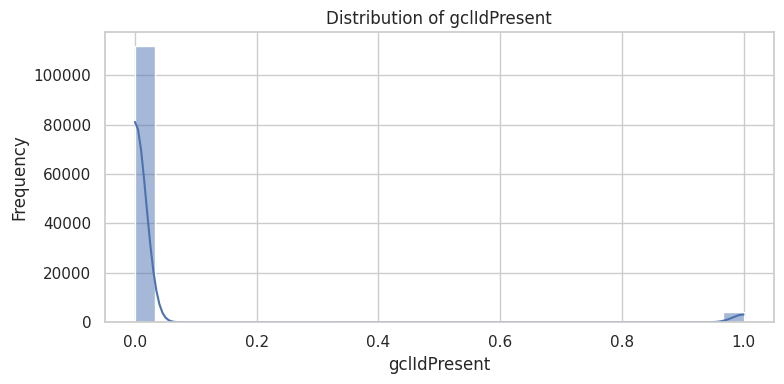

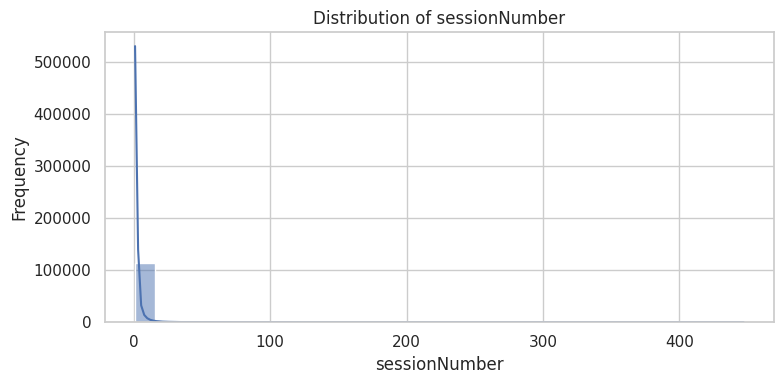

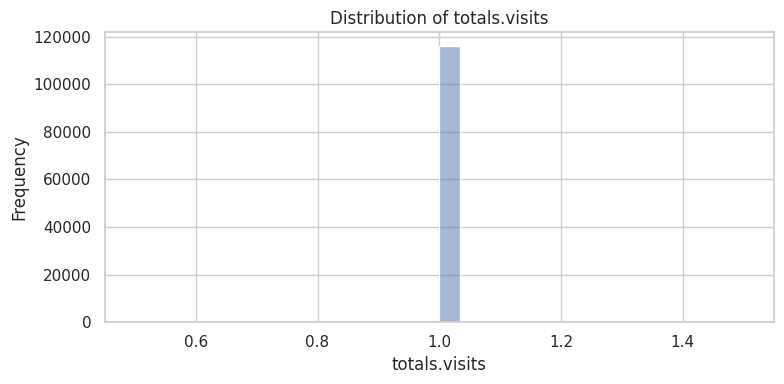

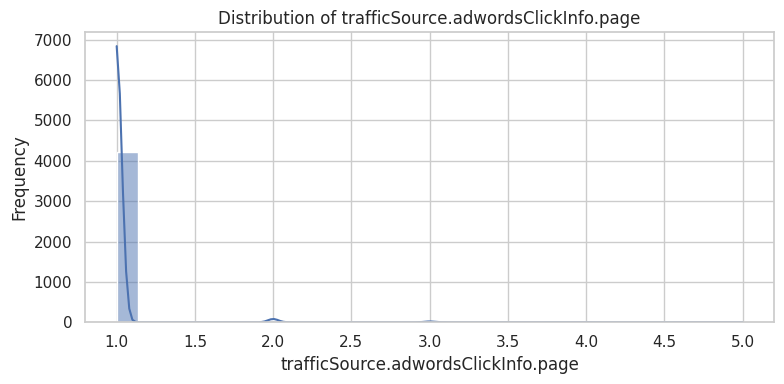

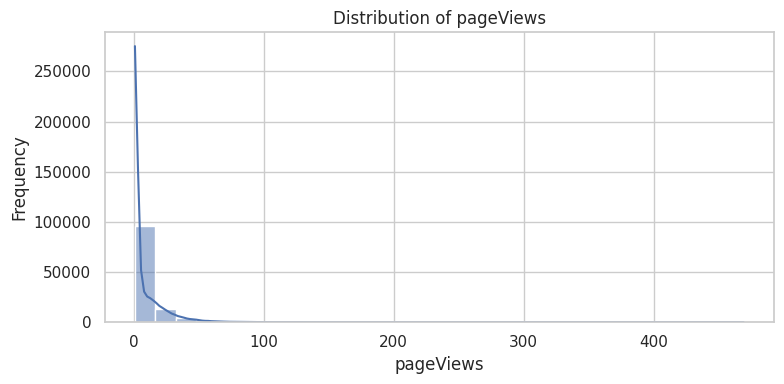

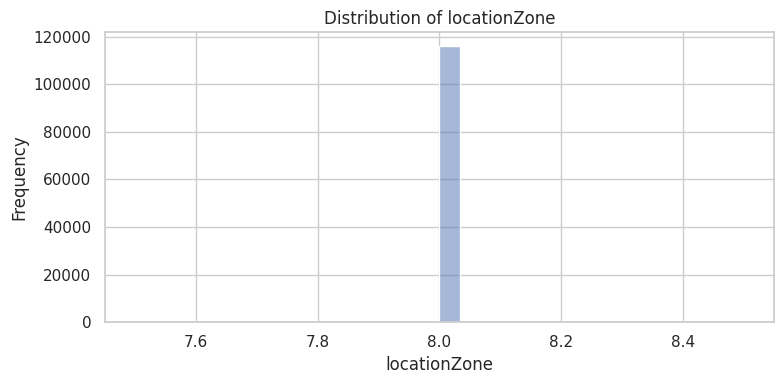

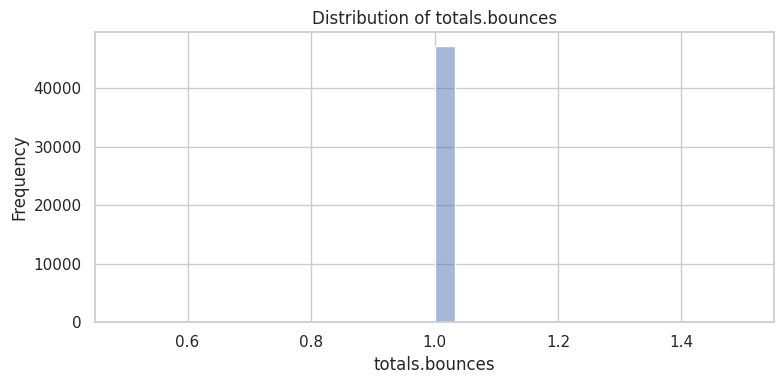

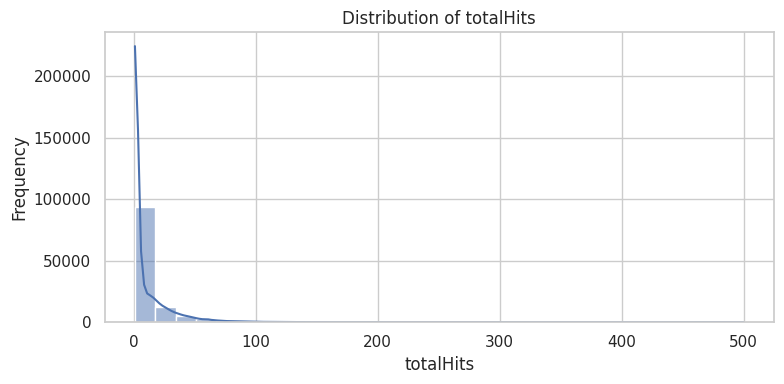

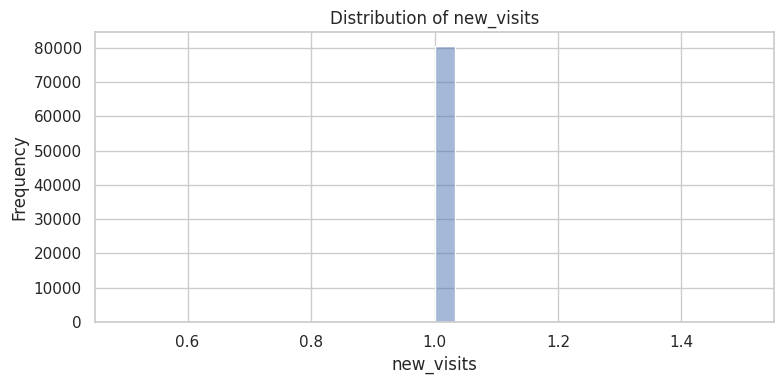

In [16]:
identifier_like = {"userId", "sessionId", "sessionStart", "date"}

numeric_predictors = [
    column
    for column in raw_train.select_dtypes(include=["number"]).columns
    if column != TARGET and column not in identifier_like
][:12]

for column in numeric_predictors:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.histplot(raw_train[column], bins=30, kde=True, ax=ax)
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()

### 2.2 Correlation among numerical variables

Correlation is used as an exploratory diagnostic, not as the sole basis for feature removal. A low Pearson correlation does not imply that a feature is useless to nonlinear tree-based models.

Removed from correlation analysis:
['locationZone', 'new_visits', 'totals.bounces', 'totals.visits']


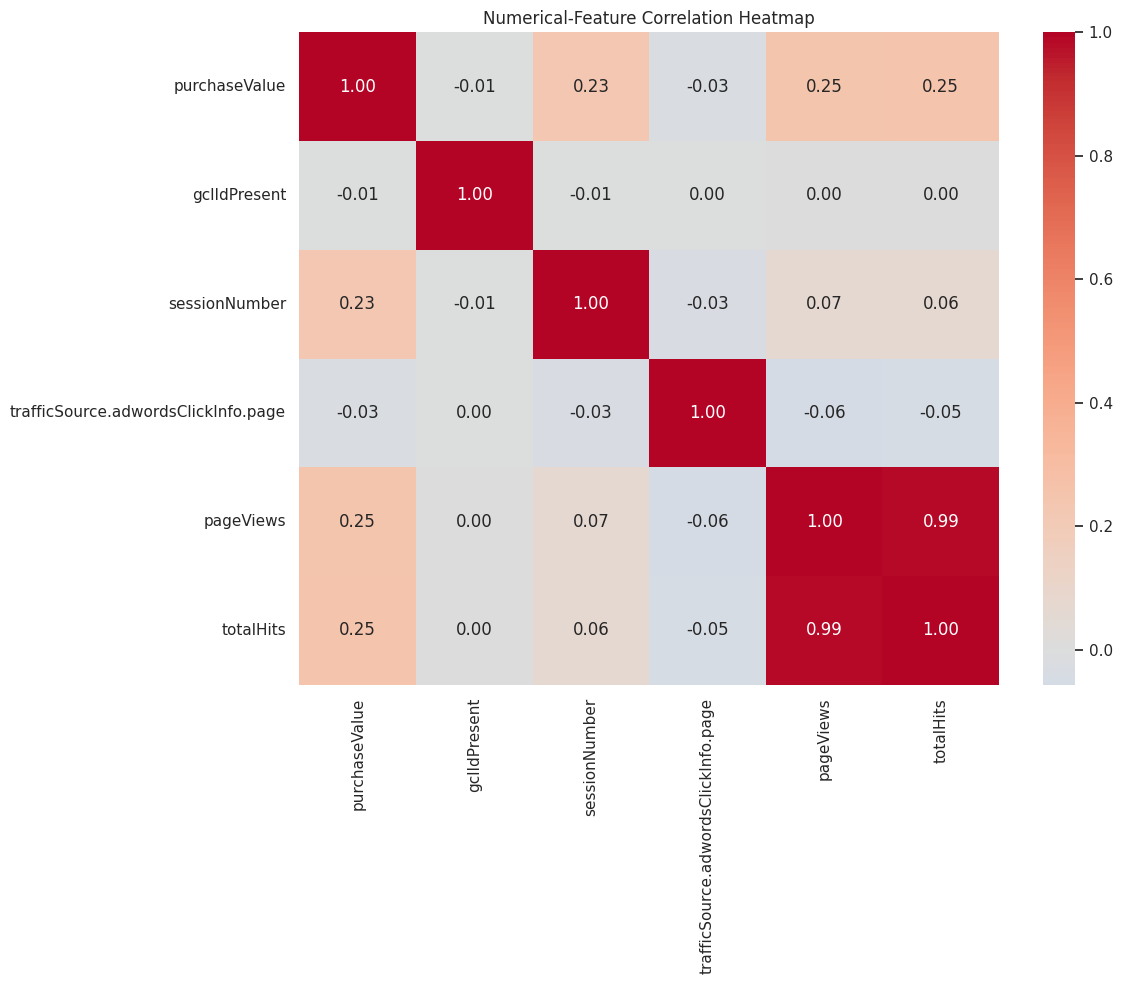

,Correlation with purchaseValue
totalHits,0.251651
pageViews,0.248454
sessionNumber,0.230585
trafficSource.adwordsClickInfo.page,-0.025839
gclIdPresent,-0.005652


In [30]:
# Select numeric columns
numeric_for_correlation = raw_train.select_dtypes(include=["number"]).copy()

# Remove identifiers and raw time/index-like columns
numeric_for_correlation = numeric_for_correlation.drop(
    columns=["userId", "sessionId", "sessionStart", "date"],
    errors="ignore",
)

# Remove columns that are entirely missing or constant
all_missing_columns = [
    column
    for column in numeric_for_correlation.columns
    if numeric_for_correlation[column].isna().all()
]

constant_columns = [
    column
    for column in numeric_for_correlation.columns
    if numeric_for_correlation[column].nunique(dropna=True) <= 1
]

columns_to_remove = sorted(set(all_missing_columns + constant_columns))

print("Removed from correlation analysis:")
print(columns_to_remove)

numeric_for_correlation = numeric_for_correlation.drop(
    columns=columns_to_remove,
    errors="ignore",
)

# True correlation matrix
correlation_matrix = (
    numeric_for_correlation
    .corr()
    .replace([np.inf, -np.inf], np.nan)
)

# Plot-only matrix: replace NaNs only for visualization
correlation_matrix_for_plot = correlation_matrix.fillna(0)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)

    fig, ax = plt.subplots(figsize=(12, 10))

    sns.heatmap(
        correlation_matrix_for_plot,
        cmap="coolwarm",
        center=0,
        annot=True,
        fmt=".2f",
        ax=ax,
    )

    ax.set_title("Numerical-Feature Correlation Heatmap")
    plt.tight_layout()
    plt.show()

# Target correlations from the true matrix, not the filled plotting matrix
target_correlations = (
    correlation_matrix[TARGET]
    .drop(TARGET)
    .dropna()
    .sort_values(
        key=lambda series: series.abs(),
        ascending=False,
    )
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    display(
        target_correlations.to_frame(
            "Correlation with purchaseValue"
        )
    )

Columns with undefined correlations were removed or excluded from the target-correlation table. Remaining NaN correlations, if any, were filled with zero only for heatmap visualization.

The strongest simple numerical relationships generally come from engagement variables such as page views, total hits, and session number. Highly correlated predictor pairs can indicate redundancy, but their usefulness is ultimately determined through validation.

### 2.3 Target distribution and outlier diagnostics

Share of zero purchase sessions: 79.33%
Target skewness: 53.91


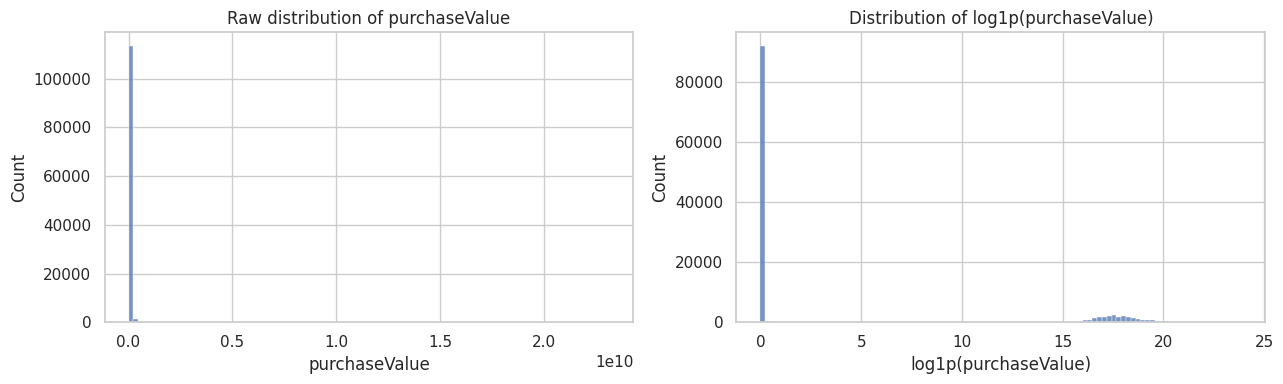

Outliers using |z| > 2.5: 1013
Outliers using the IQR rule: 23985


In [18]:
target_series = raw_train[TARGET].dropna()

print(f"Share of zero purchase sessions: {target_series.eq(0).mean():.2%}")
print(f"Target skewness: {target_series.skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(target_series, bins=100, ax=axes[0])
axes[0].set_title("Raw distribution of purchaseValue")
axes[0].set_xlabel("purchaseValue")

sns.histplot(np.log1p(target_series), bins=100, ax=axes[1])
axes[1].set_title("Distribution of log1p(purchaseValue)")
axes[1].set_xlabel("log1p(purchaseValue)")

plt.tight_layout()
plt.show()

target_z_scores = zscore(target_series)
z_outlier_count = int((np.abs(target_z_scores) > 2.5).sum())

q1 = target_series.quantile(0.25)
q3 = target_series.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
iqr_outlier_count = int(
    ((target_series < lower_bound) | (target_series > upper_bound)).sum()
)

print(f"Outliers using |z| > 2.5: {z_outlier_count}")
print(f"Outliers using the IQR rule: {iqr_outlier_count}")

The target is strongly zero-inflated and right-skewed. Log transformation was tested in some secondary workflows, but the competition score was calculated on the original target scale. Consequently, all validation metrics reported below are also calculated on the original `purchaseValue` scale.

### 2.4 Selected categorical relationships

The following plots show a limited set of low-cardinality categorical variables to avoid a long sequence of repetitive figures.

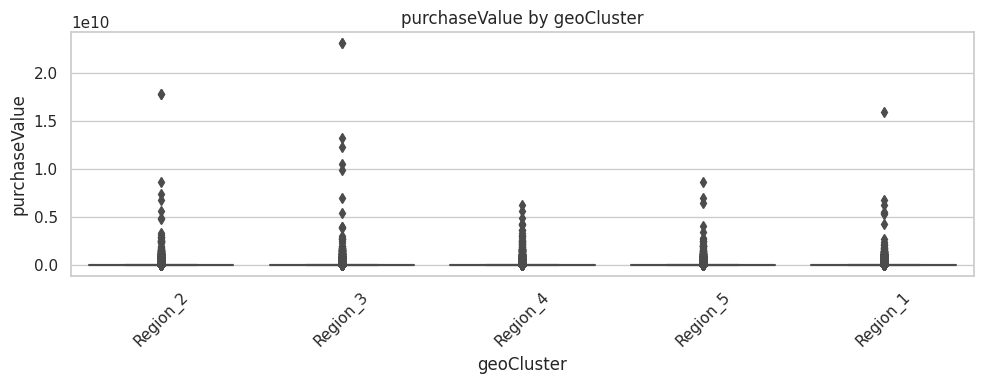

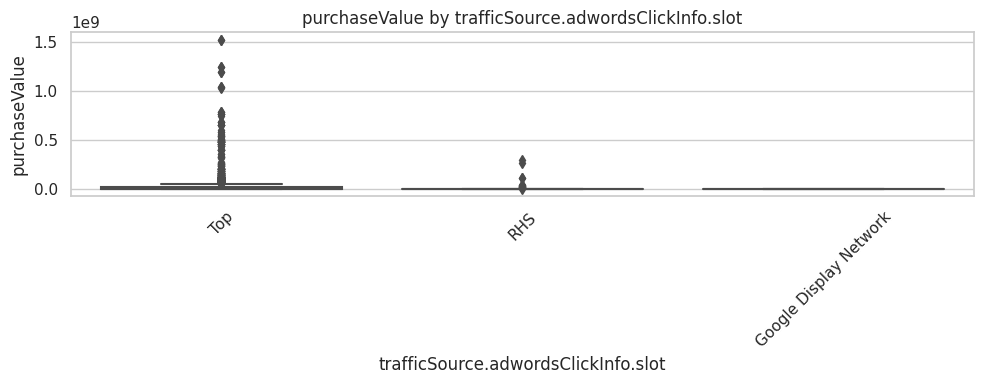

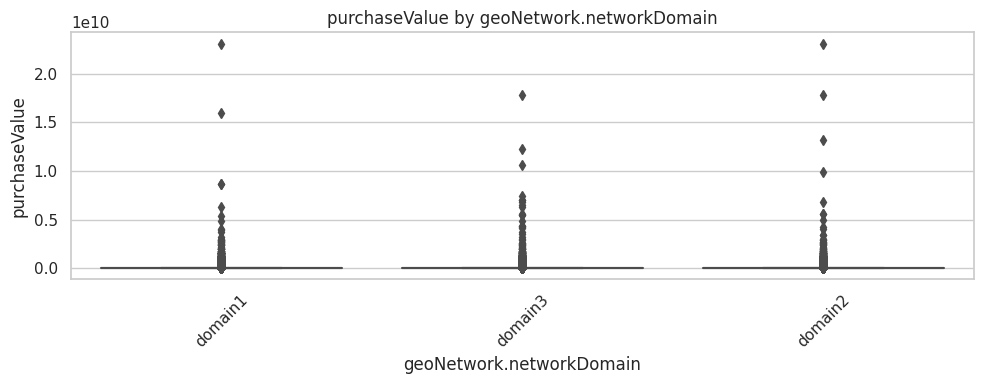

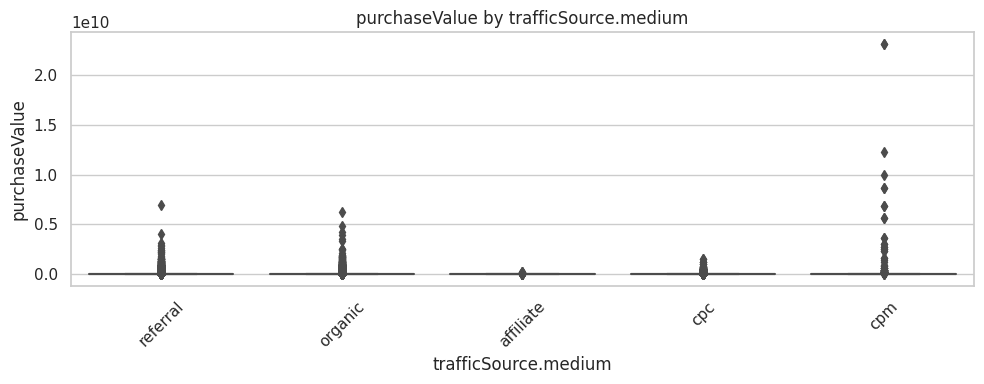

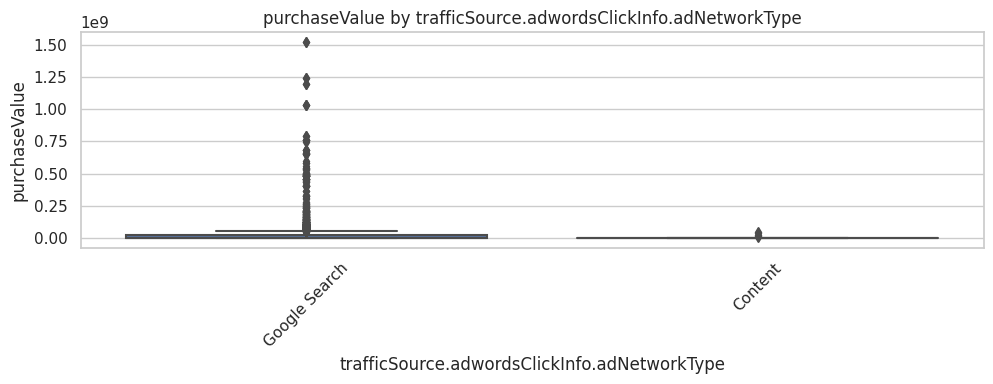

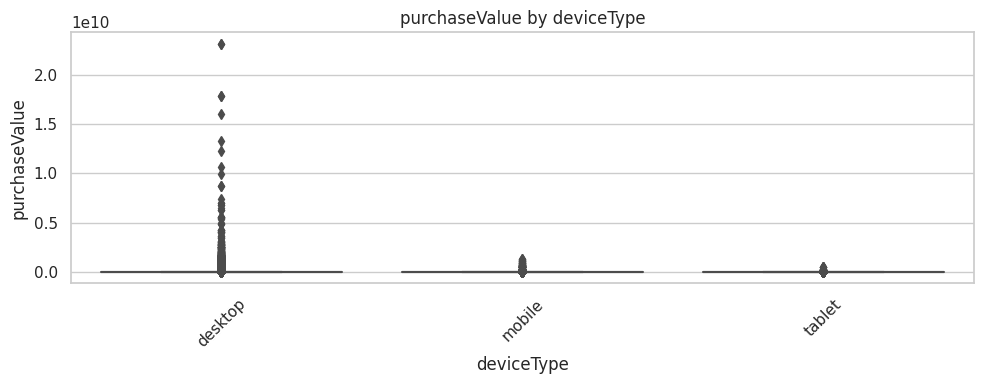

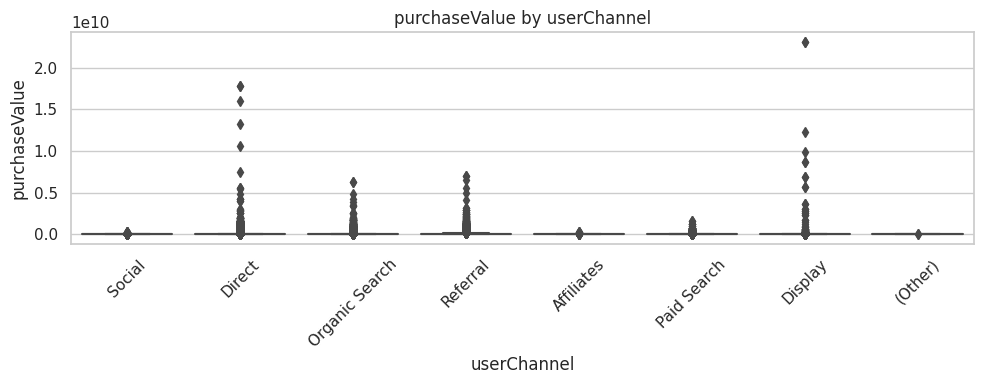

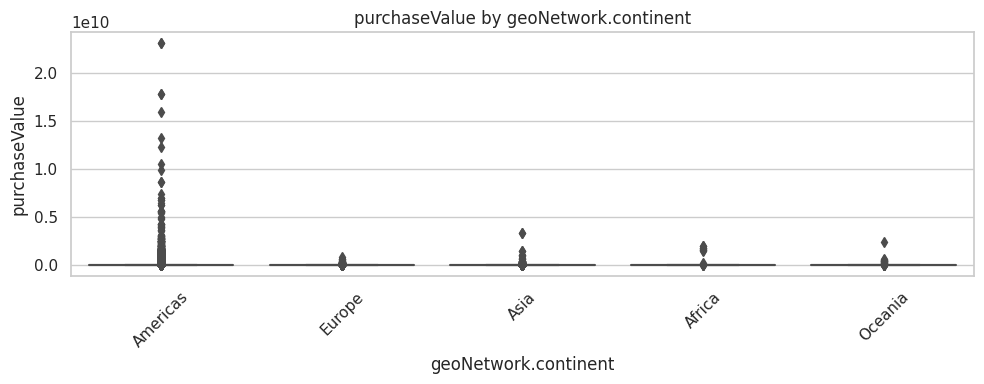

In [19]:
eda_train = raw_train.replace(PLACEHOLDERS, np.nan).dropna(subset=[TARGET]).copy()

categorical_columns = eda_train.select_dtypes(
    include=["object", "category", "bool"]
).columns

low_cardinality_categoricals = [
    column
    for column in categorical_columns
    if 2 <= eda_train[column].nunique(dropna=True) <= 10
][:8]

for column in low_cardinality_categoricals:
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.boxplot(data=eda_train, x=column, y=TARGET, ax=ax)
    ax.set_title(f"purchaseValue by {column}")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

### 2.5 Temporal patterns

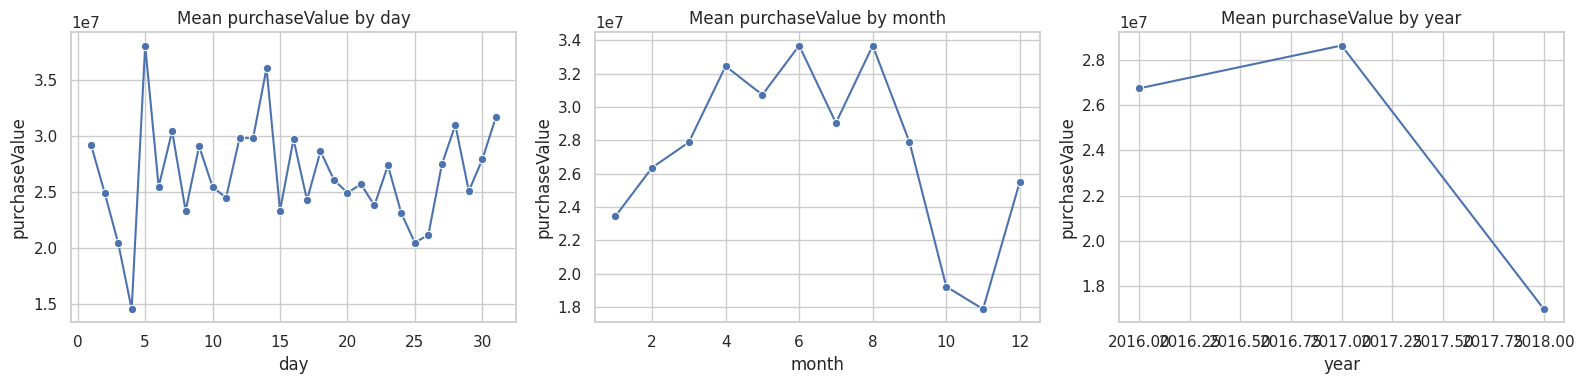

In [20]:
temporal_data = raw_train.dropna(subset=[TARGET]).copy()
temporal_data["date"] = pd.to_datetime(
    temporal_data["date"].astype("Int64").astype(str),
    format="%Y%m%d",
    errors="coerce",
)

temporal_data["day"] = temporal_data["date"].dt.day
temporal_data["month"] = temporal_data["date"].dt.month
temporal_data["year"] = temporal_data["date"].dt.year

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, period in zip(axes, ["day", "month", "year"]):
    means = temporal_data.groupby(period, as_index=False)[TARGET].mean()
    sns.lineplot(data=means, x=period, y=TARGET, marker="o", ax=ax)
    ax.set_title(f"Mean purchaseValue by {period}")

plt.tight_layout()
plt.show()

The temporal plots suggest variation across days, months, and years. These patterns are treated as candidate signals rather than firm causal conclusions, since the observations may also reflect changes in traffic volume and sample composition.

# 3. Model development

The four workflows below are intentionally kept separate because they formed distinct models in the final course submission. Shared setup code appears only once above, while each workflow performs its own feature cleaning, preprocessing, tuning, evaluation, final fitting, and submission generation.

The **XGBoost workflow is the primary model**. The other three workflows are secondary comparison models required for the project.

## 3.1 Primary model - XGBoost Regressor

The primary model uses:

- median imputation and robust scaling for numerical variables;
- ordinal encoding for low-cardinality categoricals;
- target encoding for higher-cardinality categoricals;
- date-derived day, month, and year features;
- randomized hyperparameter search;
- oversampling of non-zero purchases **only within the training partition**, leaving validation observations untouched.

In [21]:
# Fresh copies keep this workflow independent from the EDA transformations.
train_data = raw_train.copy()
test_data = raw_test.copy()

train_data = train_data.replace(PLACEHOLDERS, np.nan).infer_objects(copy=False)
test_data = test_data.replace(PLACEHOLDERS, np.nan).infer_objects(copy=False)

train_data = train_data.dropna(subset=[TARGET]).copy()

for frame in [train_data, test_data]:
    frame["date"] = pd.to_datetime(
        frame["date"].astype("Int64").astype(str),
        format="%Y%m%d",
        errors="coerce",
    )
    frame["day"] = frame["date"].dt.day
    frame["month"] = frame["date"].dt.month
    frame["year"] = frame["date"].dt.year
    frame.drop(columns="date", inplace=True)

features = train_data.drop(columns=TARGET).copy()
target = train_data[TARGET].astype(float).copy()

manual_drop = ["new_visits", "totals.bounces"]
features = features.drop(columns=manual_drop, errors="ignore")
test_data = test_data.drop(columns=manual_drop, errors="ignore")

mostly_missing_columns = [
    column
    for column in features.columns
    if features[column].isna().mean() >= 0.90
]
features = features.drop(columns=mostly_missing_columns, errors="ignore")
test_data = test_data.drop(columns=mostly_missing_columns, errors="ignore")

constant_columns = [
    column
    for column in features.columns
    if features[column].nunique(dropna=False) <= 1
]
features = features.drop(columns=constant_columns, errors="ignore")
test_data = test_data.drop(columns=constant_columns, errors="ignore")

high_cardinality_columns = [
    column
    for column in features.columns
    if features[column].nunique(dropna=True) > 10_000
]
features = features.drop(columns=high_cardinality_columns, errors="ignore")
test_data = test_data.drop(columns=high_cardinality_columns, errors="ignore")

test_data = test_data.reindex(columns=features.columns)

calendar_columns = [
    column for column in ["day", "month", "year"]
    if column in features.columns
]

numerical_columns = [
    column
    for column in features.select_dtypes(include=["number"]).columns
    if column not in calendar_columns
]

categorical_columns = features.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()
categorical_columns.extend(calendar_columns)

low_cardinality_columns = [
    column
    for column in categorical_columns
    if features[column].nunique(dropna=True) <= 10
]
higher_cardinality_columns = [
    column
    for column in categorical_columns
    if column not in low_cardinality_columns
]

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])

low_cardinality_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "ordinal",
        OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
        ),
    ),
])

higher_cardinality_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "target_encoder",
        TargetEncoder(
            handle_missing="value",
            handle_unknown="value",
        ),
    ),
])

preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_columns),
    ("low_cardinality", low_cardinality_pipeline, low_cardinality_columns),
    ("higher_cardinality", higher_cardinality_pipeline, higher_cardinality_columns),
])

X_train, X_valid, y_train, y_valid = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=target.gt(0),
)

# Oversample non-zero purchases only in the training partition.
training_partition = X_train.copy()
training_partition[TARGET] = y_train.to_numpy()

zero_training = training_partition[training_partition[TARGET] == 0]
non_zero_training = training_partition[training_partition[TARGET] > 0]

sampled_non_zero_training = non_zero_training.sample(
    n=int(len(zero_training) * 3),
    replace=True,
    random_state=RANDOM_STATE,
)

balanced_training = pd.concat(
    [zero_training, sampled_non_zero_training],
    ignore_index=True,
).sample(frac=1, random_state=RANDOM_STATE)

X_balanced = balanced_training.drop(columns=TARGET)
y_balanced = balanced_training[TARGET]

xgb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    (
        "model",
        XGBRegressor(
            objective="reg:squarederror",
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbosity=0,
            tree_method="hist",
        ),
    ),
])

parameter_distributions = {
    "model__n_estimators": randint(100, 300),
    "model__max_depth": randint(3, 10),
    "model__learning_rate": uniform(0.01, 0.10),
    "model__subsample": uniform(0.60, 0.40),
    "model__colsample_bytree": uniform(0.60, 0.40),
    "model__min_child_weight": randint(1, 6),
    "model__gamma": uniform(0.00, 0.30),
}

xgb_iterations = 200 if FULL_SEARCH else 20

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=parameter_distributions,
    n_iter=xgb_iterations,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True,
)

xgb_search.fit(X_balanced, y_balanced)

xgb_validation_predictions = np.clip(
    xgb_search.predict(X_valid),
    0,
    None,
)

xgb_metrics = evaluate_predictions(
    "XGBoost Regressor",
    y_valid,
    xgb_validation_predictions,
)
model_results.append(xgb_metrics)

print("Best XGBoost parameters:")
print(xgb_search.best_params_)

# Refit the selected model on an oversampled version of the complete training data.
full_training = features.copy()
full_training[TARGET] = target.to_numpy()

full_zero = full_training[full_training[TARGET] == 0]
full_non_zero = full_training[full_training[TARGET] > 0]

sampled_full_non_zero = full_non_zero.sample(
    n=int(len(full_zero) * 3),
    replace=True,
    random_state=RANDOM_STATE,
)

balanced_full_training = pd.concat(
    [full_zero, sampled_full_non_zero],
    ignore_index=True,
).sample(frac=1, random_state=RANDOM_STATE)

final_xgb_model = clone(xgb_search.best_estimator_)
final_xgb_model.fit(
    balanced_full_training.drop(columns=TARGET),
    balanced_full_training[TARGET],
)

xgb_test_predictions = final_xgb_model.predict(test_data)

xgb_submission = save_submission(
    xgb_test_predictions,
    "submission_xgboost.csv",
    sample_submission,
)

display(xgb_submission.head())

Fitting 3 folds for each of 200 candidates, totalling 600 fits
XGBoost Regressor
R²:   0.6994
MAE:  26758348.63
RMSE: 102667729.74
Best XGBoost parameters:
{'model__colsample_bytree': 0.6579579488364892, 'model__gamma': 0.1468358280832689, 'model__learning_rate': 0.10856504541106007, 'model__max_depth': 9, 'model__min_child_weight': 4, 'model__n_estimators': 282, 'model__subsample': 0.9046478461314871}
Saved submission_xgboost.csv


,ID,purchaseValue
0,0,42387548.0
1,1,15415266.0
2,2,2687506.0
3,3,52415704.0
4,4,0.0


XGBoost is the primary model because sequential boosting can capture nonlinear effects and feature interactions that are difficult for linear models. The validation score printed above is calculated on an untouched holdout set after correcting the oversampling order.

### XGBoost Feature Importance

After selecting XGBoost as the primary model, feature importance was examined to understand which transformed predictors contributed most strongly to the final predictions. This step helps interpret the model beyond its validation score by showing which behavioral, traffic-source, device, and geographic signals were most influential in estimating session-level purchase value.

The plot below shows the top transformed features ranked by their learned importance in the final XGBoost model.

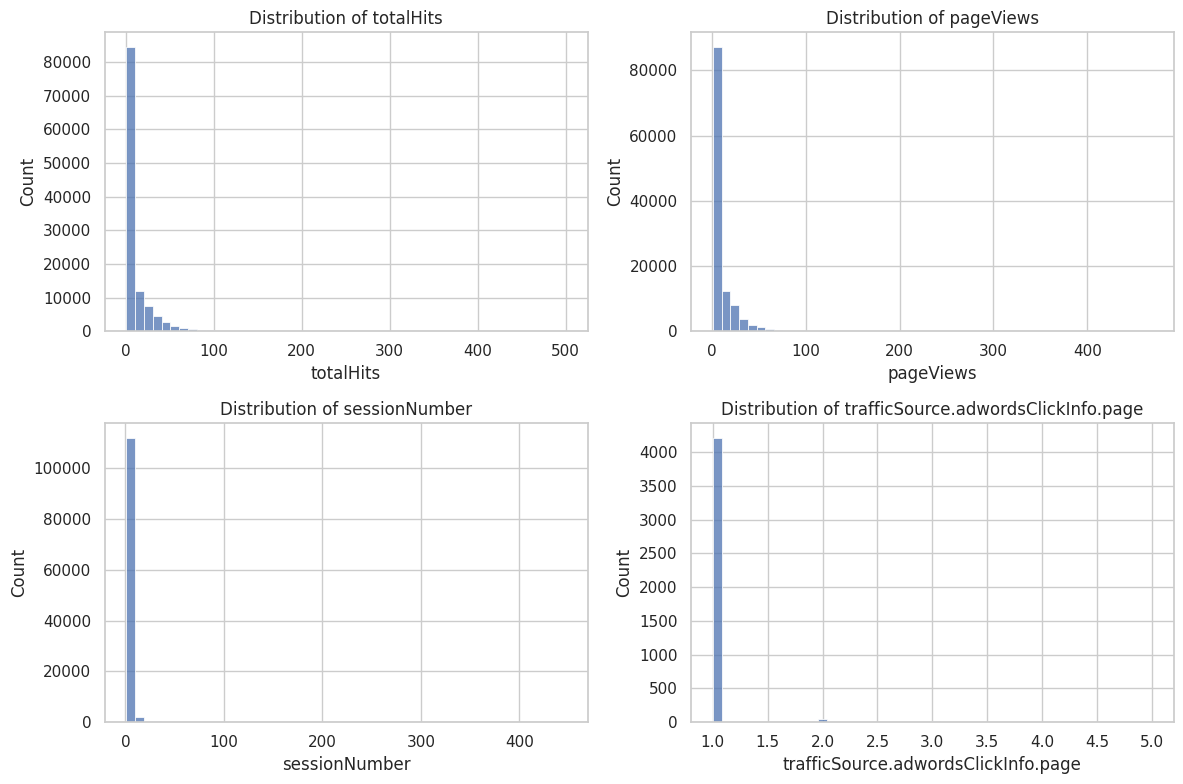

In [35]:
selected_features = [
    "totalHits",
    "pageViews",
    "sessionNumber",
    "trafficSource.adwordsClickInfo.page"
]

available_features = [
    feature for feature in selected_features
    if feature in raw_train.columns
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 8)
)

axes = axes.flatten()

for ax, feature in zip(axes, available_features):
    sns.histplot(
        raw_train[feature].dropna(),
        bins=50,
        ax=ax
    )
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")

for ax in axes[len(available_features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## 3.2 Secondary model 1 - Random Forest Regressor

This secondary workflow trains an ensemble of independently fitted decision trees. The model is trained on `log1p(purchaseValue)` to reduce the influence of the heavy right tail, but predictions are converted back to the original scale before calculating all reported metrics.

In [22]:
train_data = raw_train.copy()
test_data = raw_test.copy()

train_data = train_data.dropna(subset=[TARGET]).copy()

features = train_data.drop(columns=TARGET).copy()
target_original = train_data[TARGET].astype(float).copy()

mostly_missing_columns = [
    column
    for column in features.columns
    if features[column].isna().mean() > 0.70
]
features = features.drop(columns=mostly_missing_columns, errors="ignore")
test_data = test_data.drop(columns=mostly_missing_columns, errors="ignore")

high_cardinality_columns = ["userId", "sessionId", "sessionStart"]
features = features.drop(columns=high_cardinality_columns, errors="ignore")
test_data = test_data.drop(columns=high_cardinality_columns, errors="ignore")

constant_columns = [
    column
    for column in features.columns
    if features[column].nunique(dropna=False) <= 1
]
features = features.drop(columns=constant_columns, errors="ignore")
test_data = test_data.drop(columns=constant_columns, errors="ignore")

test_data = test_data.reindex(columns=features.columns)

numerical_columns = features.select_dtypes(include=["number"]).columns.tolist()
categorical_columns = features.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

preprocessor = ColumnTransformer([
    (
        "numerical",
        SimpleImputer(strategy="median"),
        numerical_columns,
    ),
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "one_hot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    min_frequency=5,
                    sparse_output=True,
                ),
            ),
        ]),
        categorical_columns,
    ),
])

X_train, X_valid, y_train_original, y_valid_original = train_test_split(
    features,
    target_original,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=target_original.gt(0),
)

y_train_log = np.log1p(y_train_original)

random_forest_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    (
        "model",
        RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
    ),
])

if FULL_SEARCH:
    random_forest_grid = {
        "model__n_estimators": [100, 200],
        "model__max_depth": [10, 20, None],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
        "model__max_features": ["sqrt", "log2"],
    }
else:
    random_forest_grid = {
        "model__n_estimators": [100],
        "model__max_depth": [10, None],
        "model__min_samples_split": [2],
        "model__min_samples_leaf": [1],
        "model__max_features": ["sqrt"],
    }

random_forest_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=random_forest_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1,
    refit=True,
)

random_forest_search.fit(X_train, y_train_log)

random_forest_validation_log = random_forest_search.predict(X_valid)
random_forest_validation_predictions = np.expm1(
    random_forest_validation_log
)

random_forest_metrics = evaluate_predictions(
    "Random Forest Regressor",
    y_valid_original,
    random_forest_validation_predictions,
)
model_results.append(random_forest_metrics)

print("Best Random Forest parameters:")
print(random_forest_search.best_params_)

final_random_forest = clone(random_forest_search.best_estimator_)
final_random_forest.fit(features, np.log1p(target_original))

random_forest_test_predictions = np.expm1(
    final_random_forest.predict(test_data)
)

random_forest_submission = save_submission(
    random_forest_test_predictions,
    "submission_random_forest.csv",
    sample_submission,
)

display(random_forest_submission.head())

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Random Forest Regressor
R²:   0.0235
MAE:  24851587.06
RMSE: 185055365.90
Best Random Forest parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Saved submission_random_forest.csv


,ID,purchaseValue
0,0,2879.010297
1,1,2.522086
2,2,0.430431
3,3,28.485618
4,4,0.376979


Random Forest provides a nonlinear ensemble benchmark. Unlike XGBoost, its trees are not added sequentially to correct earlier residuals. Its performance therefore serves as a useful comparison rather than the primary submission.

## 3.3 Secondary model 2 - Decision Tree Regressor

The Decision Tree workflow provides a single-tree benchmark. It is interpretable and flexible, but it is generally more sensitive to overfitting than ensemble tree methods.

In [23]:
train_data = raw_train.copy()
test_data = raw_test.copy()

train_data = train_data.dropna(subset=[TARGET]).copy()

features = train_data.drop(columns=TARGET).copy()
target_original = train_data[TARGET].astype(float).copy()

mostly_missing_columns = [
    column
    for column in features.columns
    if features[column].isna().mean() > 0.95
]
features = features.drop(columns=mostly_missing_columns, errors="ignore")
test_data = test_data.drop(columns=mostly_missing_columns, errors="ignore")

high_cardinality_columns = ["userId", "sessionId", "sessionStart"]
features = features.drop(columns=high_cardinality_columns, errors="ignore")
test_data = test_data.drop(columns=high_cardinality_columns, errors="ignore")

constant_columns = [
    column
    for column in features.columns
    if features[column].nunique(dropna=False) <= 1
]
features = features.drop(columns=constant_columns, errors="ignore")
test_data = test_data.drop(columns=constant_columns, errors="ignore")

test_data = test_data.reindex(columns=features.columns)

numerical_columns = features.select_dtypes(include=["number"]).columns.tolist()
categorical_columns = features.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

preprocessor = ColumnTransformer([
    (
        "numerical",
        SimpleImputer(strategy="median"),
        numerical_columns,
    ),
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "one_hot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    min_frequency=5,
                    sparse_output=True,
                ),
            ),
        ]),
        categorical_columns,
    ),
])

X_train, X_valid, y_train_original, y_valid_original = train_test_split(
    features,
    target_original,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=target_original.gt(0),
)

y_train_log = np.log1p(y_train_original)

decision_tree_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", DecisionTreeRegressor(random_state=RANDOM_STATE)),
])

if FULL_SEARCH:
    decision_tree_grid = {
        "model__max_depth": [4, 6, 8, 10, 12],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": [None, "sqrt"],
    }
else:
    decision_tree_grid = {
        "model__max_depth": [6, 10],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
        "model__max_features": [None],
    }

decision_tree_search = GridSearchCV(
    estimator=decision_tree_pipeline,
    param_grid=decision_tree_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1,
    refit=True,
)

decision_tree_search.fit(X_train, y_train_log)

decision_tree_validation_log = decision_tree_search.predict(X_valid)
decision_tree_validation_predictions = np.expm1(
    decision_tree_validation_log
)

decision_tree_metrics = evaluate_predictions(
    "Decision Tree Regressor",
    y_valid_original,
    decision_tree_validation_predictions,
)
model_results.append(decision_tree_metrics)

print("Best Decision Tree parameters:")
print(decision_tree_search.best_params_)

final_decision_tree = clone(decision_tree_search.best_estimator_)
final_decision_tree.fit(features, np.log1p(target_original))

decision_tree_test_predictions = np.expm1(
    final_decision_tree.predict(test_data)
)

decision_tree_submission = save_submission(
    decision_tree_test_predictions,
    "submission_decision_tree.csv",
    sample_submission,
)

display(decision_tree_submission.head())

Fitting 3 folds for each of 90 candidates, totalling 270 fits
Decision Tree Regressor
R²:   0.0206
MAE:  24473248.97
RMSE: 185331478.03
Best Decision Tree parameters:
{'model__max_depth': 8, 'model__max_features': None, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}
Saved submission_decision_tree.csv


,ID,purchaseValue
0,0,58441.348322
1,1,2.579548
2,2,0.003988
3,3,0.003988
4,4,0.000000


The single Decision Tree is expected to be less stable than the ensemble models. Its inclusion demonstrates how the additional variance reduction from Random Forest and the sequential error correction of XGBoost affect performance.

## 3.4 Secondary model 3 - Elastic Net Regressor

Elastic Net combines L1 and L2 regularization. It provides a linear baseline for determining how much performance is lost when nonlinear feature interactions are not modeled explicitly.

In [24]:
train_data = raw_train.copy()
test_data = raw_test.copy()

train_data = train_data.dropna(subset=[TARGET]).copy()

features = train_data.drop(columns=TARGET).copy()
target = train_data[TARGET].astype(float).copy()

mostly_missing_columns = [
    column
    for column in features.columns
    if features[column].isna().mean() > 0.70
]
features = features.drop(columns=mostly_missing_columns, errors="ignore")
test_data = test_data.drop(columns=mostly_missing_columns, errors="ignore")

high_cardinality_columns = ["userId", "sessionId", "date", "sessionStart"]
features = features.drop(columns=high_cardinality_columns, errors="ignore")
test_data = test_data.drop(columns=high_cardinality_columns, errors="ignore")

constant_columns = [
    column
    for column in features.columns
    if features[column].nunique(dropna=False) <= 1
]
features = features.drop(columns=constant_columns, errors="ignore")
test_data = test_data.drop(columns=constant_columns, errors="ignore")

test_data = test_data.reindex(columns=features.columns)

numerical_columns = features.select_dtypes(include=["number"]).columns.tolist()
categorical_columns = features.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numerical_columns,
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "one_hot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        min_frequency=5,
                        sparse_output=True,
                    ),
                ),
            ]),
            categorical_columns,
        ),
    ],
    sparse_threshold=1.0,
)

X_train, X_valid, y_train, y_valid = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=target.gt(0),
)

elastic_net_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    (
        "model",
        ElasticNet(
            random_state=RANDOM_STATE,
            max_iter=20_000,
        ),
    ),
])

if FULL_SEARCH:
    elastic_net_grid = {
        "model__alpha": [0.01, 0.1, 1.0],
        "model__l1_ratio": [0.3, 0.5, 0.7],
    }
else:
    elastic_net_grid = {
        "model__alpha": [0.1, 1.0],
        "model__l1_ratio": [0.5],
    }

elastic_net_search = GridSearchCV(
    estimator=elastic_net_pipeline,
    param_grid=elastic_net_grid,
    scoring="r2",
    n_jobs=-1,
    cv=3,
    verbose=1,
    refit=True,
)

elastic_net_search.fit(X_train, y_train)

elastic_net_validation_predictions = np.clip(
    elastic_net_search.predict(X_valid),
    0,
    None,
)

elastic_net_metrics = evaluate_predictions(
    "Elastic Net Regressor",
    y_valid,
    elastic_net_validation_predictions,
)
model_results.append(elastic_net_metrics)

print("Best Elastic Net parameters:")
print(elastic_net_search.best_params_)

final_elastic_net = clone(elastic_net_search.best_estimator_)
final_elastic_net.fit(features, target)

elastic_net_test_predictions = final_elastic_net.predict(test_data)

elastic_net_submission = save_submission(
    elastic_net_test_predictions,
    "submission_elastic_net.csv",
    sample_submission,
)

display(elastic_net_submission.head())

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Elastic Net Regressor
R²:   0.1113
MAE:  33314710.90
RMSE: 176541863.92
Best Elastic Net parameters:
{'model__alpha': 0.01, 'model__l1_ratio': 0.7}
Saved submission_elastic_net.csv


,ID,purchaseValue
0,0,2.272636e+07
1,1,0.000000e+00
2,2,0.000000e+00
3,3,1.392517e+08
4,4,1.086906e+07


Elastic Net is expected to perform worse when the relationship between session behavior and purchase value is strongly nonlinear. Its value in the project is as a regularized linear benchmark.

The secondary models are retained as required comparison baselines. Their weaker R² values illustrate the difficulty of modeling the highly zero-inflated, heavy-tailed target and demonstrate the advantage of gradient boosting for this dataset.

# 4. Model comparison

All validation metrics below are calculated on the original `purchaseValue` scale. The Kaggle score and final rank should be added to the repository README only after being verified from the competition submission history.

In [25]:
model_comparison = (
    pd.DataFrame(model_results)
    .sort_values("Validation R2", ascending=False)
    .reset_index(drop=True)
)

display(model_comparison)

,Model,Validation R2,Validation MAE,Validation RMSE
0,XGBoost Regressor,0.699445,2.675835e+07,1.026677e+08
1,Elastic Net Regressor,0.111308,3.331471e+07,1.765419e+08
2,Random Forest Regressor,0.023530,2.485159e+07,1.850554e+08
3,Decision Tree Regressor,0.020614,2.447325e+07,1.853315e+08


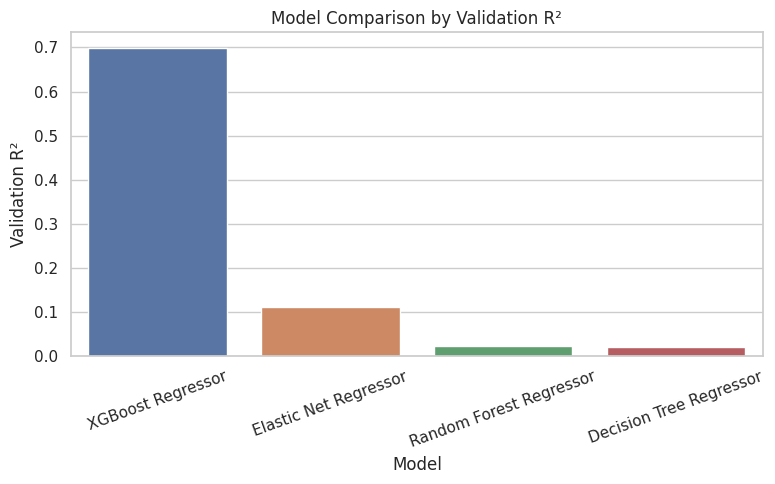

In [31]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="Validation R2"
)

plt.title("Model Comparison by Validation R²")
plt.xlabel("Model")
plt.ylabel("Validation R²")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# 5. Conclusion

This final course submission compared four regression workflows for predicting e-commerce session purchase value.

The primary XGBoost workflow was designed to handle mixed data types, nonlinear interactions, missing values, and the strongly zero-inflated target. Random Forest and Decision Tree provided nonlinear tree-based comparisons, while Elastic Net acted as a regularized linear benchmark.

## Results summary

On the untouched holdout set, the primary XGBoost model achieved:

- **Validation R²:** 0.6994
- **Validation MAE:** ₹26.76 million
- **Validation RMSE:** ₹102.67 million

XGBoost substantially outperformed the three secondary models in explained variance. The result indicates that nonlinear interactions between engagement, acquisition-channel, device, and geographic variables were important for predicting purchase value.

Random Forest and Decision Tree produced slightly lower MAE values but near-zero R² values. This suggests that they performed reasonably on the large number of zero or low-value sessions while failing to explain the variation associated with high-value purchases. XGBoost provided a better balance by capturing more of the high-value behavior.